In [4]:
import numpy as np
import time
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [5]:
vocab_size = 10000  # top 10k words

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
max_len = 200

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

In [7]:
def build_model(model_type):
    model = Sequential()

    # Embedding layer
    model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len))

    # Choose model
    if model_type == "RNN":
        model.add(SimpleRNN(64))

    elif model_type == "LSTM":
        model.add(LSTM(64))

    elif model_type == "GRU":
        model.add(GRU(64))

    # Output layer
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model

In [8]:
results = {}

for model_type in ["RNN", "LSTM", "GRU"]:
    print(f"\nTraining {model_type}...")

    model = build_model(model_type)

    start_time = time.time()

    history = model.fit(
        X_train, y_train,
        epochs=3,
        batch_size=64,
        validation_split=0.2,
        verbose=1
    )

    end_time = time.time()

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    results[model_type] = {
        "history": history,
        "loss": loss,
        "accuracy": accuracy,
        "time": end_time - start_time
    }


Training RNN...
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 100ms/step - accuracy: 0.6524 - loss: 0.5982 - val_accuracy: 0.7876 - val_loss: 0.4769
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 94ms/step - accuracy: 0.8050 - loss: 0.4240 - val_accuracy: 0.6566 - val_loss: 0.6323
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 104ms/step - accuracy: 0.7598 - loss: 0.4911 - val_accuracy: 0.6896 - val_loss: 0.5930

Training LSTM...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 90s 276ms/step - accuracy: 0.7464 - loss: 0.5339 - val_accuracy: 0.7862 - val_loss: 0.4842
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 87s 278ms/step - accuracy: 0.8500 - loss: 0.3652 - val_accuracy: 0.8462 - val_loss: 0.3619
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 86s 274ms/step - accuracy: 0.9074 - loss: 0.2418 - val_accuracy: 0.8688 - val_loss: 0.3318

Training GRU...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 98s 300ms/step - accuracy: 0.7768 - loss: 0.4511 - val_accuracy: 0.8478 - val_loss: 0.3523
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 142s 299ms/step - accuracy:

In [9]:
print("\n📊 Final Comparison:")

for model_type in results:
    print(f"{model_type}:")
    print(f"Accuracy: {results[model_type]['accuracy']:.4f}")
    print(f"Loss: {results[model_type]['loss']:.4f}")
    print(f"Training Time: {results[model_type]['time']:.2f} sec\n")


📊 Final Comparison:
RNN:
Accuracy: 0.6933
Loss: 0.5930
Training Time: 96.03 sec

LSTM:
Accuracy: 0.8603
Loss: 0.3440
Training Time: 262.34 sec

GRU:
Accuracy: 0.8664
Loss: 0.3502
Training Time: 381.26 sec



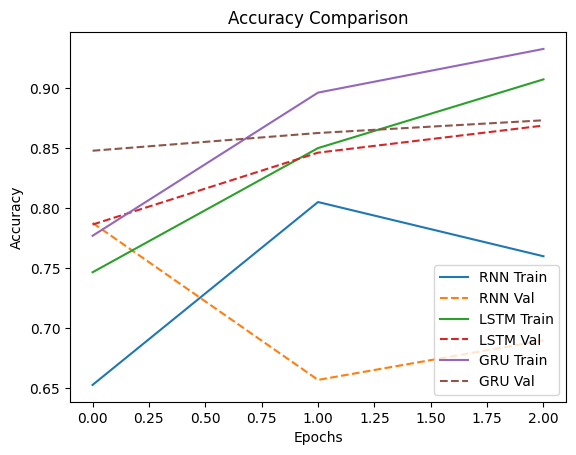

In [10]:
for model_type in results:
    history = results[model_type]["history"]

    plt.plot(history.history['accuracy'], label=f"{model_type} Train")
    plt.plot(history.history['val_accuracy'], linestyle='--', label=f"{model_type} Val")

plt.title("Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()